In [ ]:
import re
import math
import random
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as pit

random.seed(42)
np.random.seed(42)
print("setup complete")



setup complete


In [ ]:
corpus_text = """It was the first day of college, and Rohan stood outside the classroom with a nervous smile. He knew nobody. Students were laughing, introducing themselves, and choosing seats. Rohan quietly walked to the last bench and sat down.

A few minutes later, a boy named Kabir sat beside him.

“First day?” Kabir asked.

Rohan nodded. “Yeah. I don't know anyone here.”

“Same,” Kabir replied. “So now you know me.”

They both laughed.

That simple conversation became the beginning of a friendship that lasted throughout college.

Soon, their small group grew. There was Meera, who was always prepared for exams; Aditya, who was never on time; and Sana, who somehow managed to turn every serious situation into a joke. Together, they attended lectures, shared notes, skipped boring classes, ate countless samosas in the canteen, and stayed late on campus before exams.

But college was not always fun.

During their final year, they had to complete an important project. Everyone was stressed. Their first presentation went badly, and the professor rejected their idea.

“We should give up and choose something easier,” Aditya said.

Rohan shook his head. “We've come this far. Let's try once more.”

For the next two weeks, they worked together every evening. Meera handled the research, Sana designed the presentation, Aditya worked on the technical part, and Rohan coordinated everything.

On presentation day, they stood nervously in front of the class.

This time, everything went perfectly.

The professor smiled and said, “Excellent work. You should be proud of yourselves.”

They looked at each other and smiled.

A few weeks later, graduation day arrived.

The same classroom that once felt unfamiliar was now filled with memories. They took photos, exchanged signatures, and promised to stay in touch.

As Rohan walked out of the college gate, he stopped for a moment and looked back.

He realized that college had given him much more than a degree. It had given him confidence, unforgettable memories, failures that taught him lessons, and friends who had become family.

Years later, whenever they met, they always talked about the same thing—the last bench.

Because sometimes, the best stories of college begin with simply choosing a seat.
"""

print(f"Corpus length: {len(corpus_text)} characters")

Corpus length: 2247 characters


In [ ]:
def tokenize(text):
  """ a simple, dependency-free tokenizer;lowercase + extract word tokens."""
  # Ensure text is a string and convert to lowercase
  text = str(text).lower()
  tokens = re.findall(r"[a-z']+", text)
  return tokens

# Call the tokenize function and print results
tokens = tokenize(corpus_text)
print("first 50 tokens:", tokens[:50])
print(f"\ntotal tokens: {len(tokens)}")
print(f"unique vocabs: {len(set(tokens))}")

first 50 tokens: ['it', 'was', 'the', 'first', 'day', 'of', 'college', 'and', 'rohan', 'stood', 'outside', 'the', 'classroom', 'with', 'a', 'nervous', 'smile', 'he', 'knew', 'nobody', 'students', 'were', 'laughing', 'introducing', 'themselves', 'and', 'choosing', 'seats', 'rohan', 'quietly', 'walked', 'to', 'the', 'last', 'bench', 'and', 'sat', 'down', 'a', 'few', 'minutes', 'later', 'a', 'boy', 'named', 'kabir', 'sat', 'beside', 'him', 'first']

total tokens: 361
unique vocabs: 217


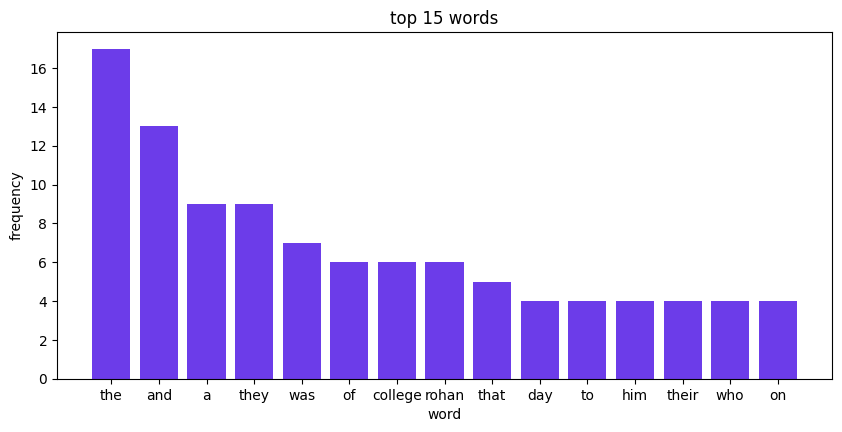

In [ ]:
#word frequency--and  alive look at zipf's law
freq = Counter(tokens)
top_word = freq.most_common(15)

words,counts = zip(*top_word)
pit.figure(figsize=(10, 4.5))
pit.bar(words, counts, color="#6C3CE9")
pit.title("top 15 words")
pit.ylabel("frequency")
pit.xlabel("word")
pit.show()

In [1]:
!pip install -q transformers
from transformers import pipeline, set_seed
generator = pipeline("text-generation", model="gpt2")
print("GPT-2 is loaded and ready to write.")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

GPT-2 is loaded and ready to write.


In [2]:
set_seed(42)
prompt = " the weather in pune today is "

outputs = generator(prompt, max_length=40, num_return_sequences=3)
for i , o in enumerate(outputs,1 ):
    print(f"Version {i}: {o['generated_text']}")
    print()

[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Version 1:  the weather in pune today is  very mild, the wind is not as strong as in earlier days. But the weather is still very pleasant and sunny. The weather is sunny with a few drizzle on the east coast, but it's not as tropical as in past years. The sun still shines and the clouds still shine. The climate is good in the north-east, but in the west it is just a bit colder. The weather is good in the north-east, but the weather is not as good as in previous years. The weather is good in the north-east, but the weather is not as good as in previous years. The weather is good in the north-east, but the weather is not as good as in previous years. The weather is good in the north-east, but the weather is not as good as in previous years. The weather is good in the north-east, but the weather is not as good as in previous years. The weather is good in the north-east, but the weather is not as good as in previous years.
Weather in the North-East
The weather on the east coast is good. A l